# 03 · Etiquetado automático

**Proyecto:** EmoGol — Trabajo de grado, Universidad del Cauca  
**Autor:** Santiago Fernando Ortega Segura · **Director:** Ph.D. Oscar Mauricio Caicedo Rendón

Calibra el anotador (Qwen2.5-7B-Instruct vía Ollama, con instrucciones few-shot y reglas de desambiguación) contra la muestra etiquetada a mano y etiqueta el pool con autoconsistencia (3 votos por comentario). Se conservan los comentarios con confianza ≥ 0,67. El etiquetado del pool se hizo en varias sesiones: el notebook retoma automáticamente desde el último comentario guardado.

*Nombre durante el desarrollo: `02_Anotacion` (algunas salidas conservan esa numeración).*

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pandas scikit-learn tqdm -q

import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)

RUTA_DATA = '/content/drive/MyDrive/RUTA/A/data_prep'

RUTA_POOL = f'{RUTA_DATA}/pool_comentarios_limpios.csv'
RUTA_GOLD = f'{RUTA_DATA}/gold_set_para_anotar.csv'

Mounted at /content/drive


## 1. Cargar la muestra etiquetada a mano

In [2]:
EMOCIONES = ['alegria', 'tristeza', 'enojo', 'miedo', 'sorpresa', 'burla', 'neutral']
label2id = {e: i for i, e in enumerate(EMOCIONES)}
id2label = {i: e for i, e in enumerate(EMOCIONES)}

df_gold = pd.read_csv(RUTA_GOLD, encoding='utf-8', encoding_errors='replace')
df_gold['label'] = df_gold['label'].astype(str).str.strip().str.lower()

vacios = df_gold['label'].isin(['nan', 'none', '']) | df_gold['label'].isna()
fuera_de_canon = ~df_gold['label'].isin(EMOCIONES) & ~vacios

print(f"Total gold: {len(df_gold)}")
print(f"Sin etiqueta: {vacios.sum()}")
print(f"Etiqueta fuera de las 7 clases válidas: {fuera_de_canon.sum()}")
if fuera_de_canon.sum() > 0:
    print(df_gold.loc[fuera_de_canon, ['comment_id', 'text', 'label']])

assert vacios.sum() == 0, "Hay filas sin etiqueta en el gold set — complétalas antes de continuar."
assert fuera_de_canon.sum() == 0, "Hay etiquetas que no coinciden exactamente con las 7 clases — revísalas (típicamente tildes/mayúsculas)."

print("\nDistribución del gold set:")
print(df_gold['label'].value_counts())
print("\n% del total:")
print((df_gold['label'].value_counts(normalize=True) * 100).round(1))

Total gold: 640
Sin etiqueta: 0
Etiqueta fuera de las 7 clases válidas: 0

Distribución del gold set:
label
alegria     172
burla       156
neutral     124
enojo       102
sorpresa     44
tristeza     30
miedo        12
Name: count, dtype: int64

% del total:
label
alegria     26.9
burla       24.4
neutral     19.4
enojo       15.9
sorpresa     6.9
tristeza     4.7
miedo        1.9
Name: proportion, dtype: float64


## 2. Separar la muestra en calibración y reserva

In [3]:
from sklearn.model_selection import train_test_split

df_gold_dev, df_gold_test = train_test_split(
    df_gold,
    test_size=0.8,
    stratify=df_gold['label'],
    random_state=SEED,
)

print(f"gold_dev:  {len(df_gold_dev)} comentarios (calibración del prompt)")
print(f"gold_test: {len(df_gold_test)} comentarios (INTOCADO hasta el notebook 06)")
print("\nDistribución gold_dev:")
print(df_gold_dev['label'].value_counts())
print("\nDistribución gold_test:")
print(df_gold_test['label'].value_counts())

df_gold_test.to_csv(f'{RUTA_DATA}/gold_test.csv', index=False)
print("\ngold_test.csv guardado — no se vuelve a abrir en este notebook.")

gold_dev:  128 comentarios (calibración del prompt)
gold_test: 512 comentarios (INTOCADO hasta el notebook 06)

Distribución gold_dev:
label
alegria     34
burla       31
neutral     25
enojo       20
sorpresa     9
tristeza     6
miedo        3
Name: count, dtype: int64

Distribución gold_test:
label
alegria     138
burla       125
neutral      99
enojo        82
sorpresa     35
tristeza     24
miedo         9
Name: count, dtype: int64

gold_test.csv guardado — no se vuelve a abrir en este notebook.


## 3. Instalar y levantar Ollama

In [4]:
!sudo apt-get update -qq && sudo apt-get install -y zstd -qq
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time
subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)

!pip install ollama -q
!ollama pull qwen2.5:7b

print("Ollama + qwen2.5:7b listos")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ol

## 4. Prompt few-shot con las 7 clases confirmadas

In [5]:
import ollama
import re

FEW_SHOT = {
    "alegria":  ["Que golazo de Bruno, grande United", "Muy bien por el Napoli, se nota que es un equipo ordenado", "Que crack es Valverde, impresionante lo bueno que es"],
    "tristeza": ["Otra vez perdiendo, qué desastre, me duele", "Me duele ver a mi equipo así", "Extraño a Iñigo 😢"],
    "enojo":    [
        "Árbitro vendido, penal clarísimo",
        "LA BASURA DE ESPN APOYANDO ESA ESTAFA",
        "Que le hicieron a la Juve, un desastre, esto es una vergüenza",
        "El gol que se come Neuer es terrible",
        "Total fracaso del Marsella.",
    ],
    "miedo":    ["No aguanto los nervios, se nos puede escapar en el último minuto", "Ojalá no nos remonten, qué susto", "Cuidado con esta eliminatoria, se puede complicar"],
    "sorpresa": ["No puedo creer ese remate desde fuera del área", "Primera vez que veo un partido así, no me lo esperaba", "Es sorprendente cómo remontaron en 5 minutos"],
    "burla":    [
        "El United ya no aprende, enseña",
        "Que amargos son para festejar jaja",
        "Equipo de muertos este, se durmieron en su propio arco 😂",
        "Felicidades al equipo, mañana se define contra quién van a perder en la final",
        "Que grande es, desapareció del partido",
        "Cuando va a dejar de cantar este comentarista",
        "Esa defensa la pasamos hasta nosotros que jugamos caimaneras en el barrio",
    ],
    "neutral":  [
        "El partido terminó 3-2",
        "Jugaron bien ambos equipos",
        "¿Cuántos años lleva Pep en el City?",
        "Recuerdo la goleada del Ajax al Madrid y ahora el Napoli al Ajax",
        "Las veces que fue eliminado el Madrid nunca ponen portada del DT",
    ],
}

REGLAS = """
Reglas para desambiguar (aplícalas en este orden):
1. Si el comentario usa "jaja", "jeje", "xd", "lol" o emojis de risa/burla (\U0001F602\U0001F923\U0001F921) junto con una crítica o la desgracia de alguien (rival o propio equipo), es BURLA, no alegria/tristeza/enojo.
2. Es BURLA (no alegría, ni enojo, ni tristeza) cualquiera de estos patrones sin necesidad de "jaja": (a) un elogio o "felicitación" que en realidad es irónico o se contradice a sí mismo; (b) una pregunta retórica de fastidio o desprecio hacia alguien ("cuándo va a dejar de...", "hasta cuándo con..."); (c) una comparación hiperbólica que ridiculiza exagerando lo fácil o lo malo que es algo/alguien.
3. Elogio genuino, admiración u orgullo hacia un jugador o equipo (sin ironía ni contradicción) es ALEGRIA, no sorpresa.
4. SORPRESA solo cuando hay una señal explícita de que algo no se esperaba: "no esperaba", "no puedo creer", "primera vez que veo", o emojis de shock (\U0001F62E\U0001F62F\U0001F92D).
5. Comentario puramente informativo o analítico, sin carga emocional clara (resultado, minuto de gol, pregunta de reglas, análisis táctico, o un recuerdo/comparación de resultados pasados sin marcador emocional propio), es NEUTRAL.
6. MIEDO solo cuando el propio autor expresa su nerviosismo o temor sobre su equipo — no cuando describe en tercera persona la fama de "miedo" que da otro equipo.
7. TRISTEZA NO es la opción por defecto para tono negativo. Exige una señal léxica explícita de dolor o pena propia: palabras como "triste", "duele", "extraño a", "lastima", "pesar", o emojis de llanto (\U0001F622\U0001F62D). Palabras de queja o crítica genéricas como "terrible", "desastre", "fracaso", "vergüenza", "llorón" SIN esa señal de dolor propio son ENOJO (si critican/se quejan de alguien), no tristeza. Ante la duda entre tristeza y otra clase, elige la otra clase.
""".strip()

PATRON_RISA = re.compile(r"jaja|jeje|jiji|\bxd\b|\blol\b|\U0001F602|\U0001F923", re.IGNORECASE)
PATRON_BURLA_FUERTE = re.compile(r"\U0001F921")
CLASES_QUE_SE_CORRIGEN_POR_RISA = {"enojo", "tristeza", "neutral", "alegria"}

def generar_prompt(comentario):
    clases_str = ", ".join(EMOCIONES)
    ejemplos = "\n".join(f'"{ej}" -> {emo}' for emo, lista in FEW_SHOT.items() for ej in lista)
    plantilla = (
        "<|im_start|>system\n"
        "Eres un clasificador de emociones para comentarios de fútbol en español.\n"
        f"Categorías permitidas: [{clases_str}].\n"
        "Responde ÚNICAMENTE con una de esas palabras, en minúsculas, sin puntos ni explicaciones.\n\n"
        f"{REGLAS}\n\n"
        "Ejemplos:\n"
        f"{ejemplos}\n"
        "<|im_end|>\n"
        "<|im_start|>user\n"
        f'Comentario: "{comentario}"\n'
        "Emoción:<|im_end|>"
    )
    return plantilla

def clasificar(texto, n_votes=3, temperature=0.5):
    votos = []
    for _ in range(n_votes):
        resp = ollama.generate(model="qwen2.5:7b", prompt=generar_prompt(texto),
                                options={"temperature": temperature})
        etiqueta = resp["response"].strip().lower()
        votos.append(etiqueta if etiqueta in EMOCIONES else "no_valido")
    conteo = Counter(votos)
    etiqueta_final, votos_ganadores = conteo.most_common(1)[0]
    confianza = votos_ganadores / n_votes

    if PATRON_BURLA_FUERTE.search(texto) and etiqueta_final != "burla":
        etiqueta_final = "burla"
        confianza = min(confianza, 0.67)
    elif etiqueta_final in CLASES_QUE_SE_CORRIGEN_POR_RISA and PATRON_RISA.search(texto):
        etiqueta_final = "burla"
        confianza = min(confianza, 0.67)

    return etiqueta_final, confianza

## 5. Validar el anotador contra la muestra de calibración

In [7]:
resultados_dev = []
for _, row in tqdm(df_gold_dev.iterrows(), total=len(df_gold_dev), desc="Validando contra gold_dev"):
    pred, conf = clasificar(row['text'])
    resultados_dev.append({"comment_id": row['comment_id'], "text": row['text'],
                            "label_real": row['label'], "label_llm": pred, "confianza": conf})

df_val = pd.DataFrame(resultados_dev)
df_val.to_csv(f'{RUTA_DATA}/validacion_gold_dev.csv', index=False)

Validando contra gold_dev: 100%|██████████| 128/128 [02:19<00:00,  1.09s/it]


              precision    recall  f1-score   support

     alegria       0.73      0.88      0.80        34
    tristeza       0.57      0.67      0.62         6
       enojo       0.44      0.70      0.54        20
       miedo       1.00      0.67      0.80         3
    sorpresa       1.00      0.56      0.71         9
       burla       0.75      0.48      0.59        31
     neutral       0.62      0.52      0.57        25

    accuracy                           0.65       128
   macro avg       0.73      0.64      0.66       128
weighted avg       0.69      0.65      0.65       128



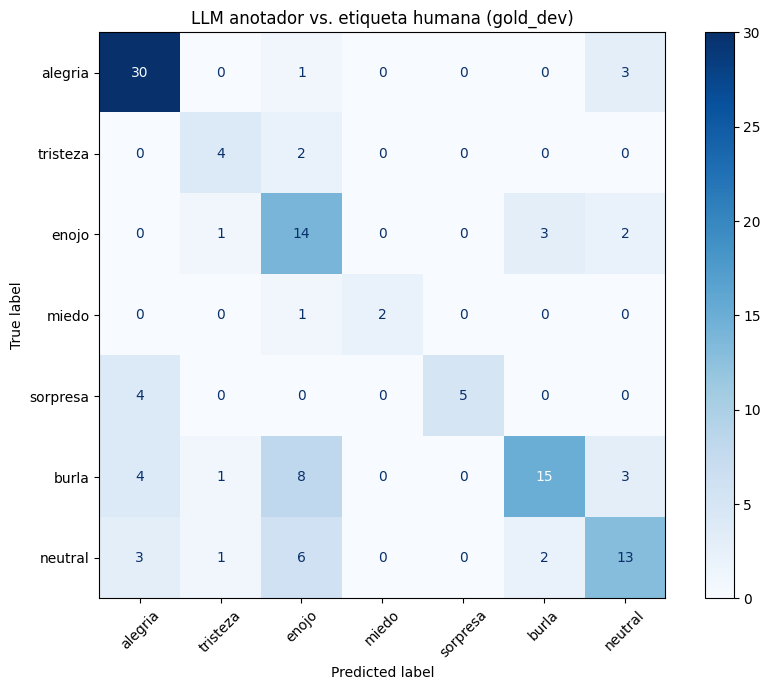


Comentarios donde el LLM no respondió una clase válida: 0


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(df_val['label_real'], df_val['label_llm'], labels=EMOCIONES, zero_division=0))

cm = confusion_matrix(df_val['label_real'], df_val['label_llm'], labels=EMOCIONES)
disp = ConfusionMatrixDisplay(cm, display_labels=EMOCIONES)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('LLM anotador vs. etiqueta humana (gold_dev)')
plt.tight_layout(); plt.show()

print("\nComentarios donde el LLM no respondió una clase válida:", (df_val['label_llm'] == 'no_valido').sum())

In [9]:
sorpresa_real = df_val[df_val['label_real'] == 'sorpresa'].copy()
sorpresa_real['acerto'] = sorpresa_real['label_llm'] == 'sorpresa'
print(f"sorpresa real: {len(sorpresa_real)} casos, acertados: {sorpresa_real['acerto'].sum()}")
print(sorpresa_real[['text', 'label_llm']].to_string())

sorpresa real: 9 casos, acertados: 5
                                                                                                                                                   text label_llm
0    dato curioso, si el PSG le gana la semifinal al Arsenal practicamente habra llegado a la final eliminando a casi todos los equipos de la premier 😯  sorpresa
40                                                                                                                  desatadooooooo...el bayer munichhh🔥   alegria
50                                                                                                             En el segundo gol nadies apretó que raro  sorpresa
57                                                                     Impresionante partido de Matías Olivera, no lo conocía pero que partido se mando   alegria
65                                                                                                       Un equipo chico ganándole al Bayern, increíble  

## 6. Etiquetar el pool completo con auto-consistencia

In [ ]:
df_pool = pd.read_csv(f'{RUTA_DATA}/pool_comentarios_limpios.csv')

N_MUESTRA = None
df_a_etiquetar = df_pool if N_MUESTRA is None else df_pool.sample(N_MUESTRA, random_state=SEED)

RUTA_PROGRESO = f'{RUTA_DATA}/pool_etiquetado_progreso.csv'
GUARDAR_CADA = 500

try:
    df_progreso = pd.read_csv(RUTA_PROGRESO)
    resultados_pool = df_progreso.to_dict('records')
    ya_etiquetados = set(df_progreso['comment_id'])
    print(f"Retomando corrida anterior: {len(ya_etiquetados)} comentarios ya etiquetados.")
except FileNotFoundError:
    resultados_pool = []
    ya_etiquetados = set()
    print("Sin progreso previo guardado -- empezando desde cero.")

df_pendientes = df_a_etiquetar[~df_a_etiquetar['comment_id'].isin(ya_etiquetados)]
print(f"Pendientes por etiquetar: {len(df_pendientes)} de {len(df_a_etiquetar)}")

for i, (_, row) in enumerate(tqdm(df_pendientes.iterrows(), total=len(df_pendientes), desc="Etiquetando pool")):
    pred, conf = clasificar(row['text'])
    resultados_pool.append({"comment_id": row['comment_id'], "text": row['text'],
                             "label": pred, "confianza": conf})
    if (i + 1) % GUARDAR_CADA == 0:
        pd.DataFrame(resultados_pool).to_csv(RUTA_PROGRESO, index=False)

df_pool_etiquetado = pd.DataFrame(resultados_pool)
df_pool_etiquetado.to_csv(RUTA_PROGRESO, index=False)
df_pool_etiquetado.to_csv(f'{RUTA_DATA}/pool_etiquetado.csv', index=False)

UMBRAL_CONFIANZA = 0.67
alta_confianza = df_pool_etiquetado['confianza'] >= UMBRAL_CONFIANZA
print(f"Etiquetados: {len(df_pool_etiquetado)}")
print(f"Con confianza >= {UMBRAL_CONFIANZA}: {alta_confianza.sum()} ({100*alta_confianza.mean():.1f}%)")
print("\nDistribución de clases (solo alta confianza):")
print(df_pool_etiquetado.loc[alta_confianza, 'label'].value_counts())

Retomando corrida anterior: 60500 comentarios ya etiquetados.
Pendientes por etiquetar: 46423 de 106923


Etiquetando pool:  36%|███▌      | 16805/46423 [1:49:16<3:05:48,  2.66it/s]

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

df_progreso = pd.read_csv(f'{RUTA_DATA}/pool_etiquetado_progreso.csv')
print(f"Comentarios etiquetados y guardados: {len(df_progreso)}")
print(df_progreso['label'].value_counts())
print(df_progreso.tail())

Mounted at /content/drive


NameError: name 'RUTA_DATA' is not defined